In [241]:
import pandas as pd
import numpy as np


df = pd.read_excel(file_path)

print(df.columns.tolist())
print(df.head())

['Year', 'Winner', 'Winner (Short)', 'Runner-Up', 'Runner-Up (Short)', 'Final Venue', 'Won By']
   Year                       Winner Winner (Short)              Runner-Up  \
0  2021          Chennai Super Kings            CSK  Kolkata Knight Riders   
1  2022               Gujarat Titans             GT       Rajasthan Royals   
2  2023          Chennai Super Kings            CSK         Gujarat Titans   
3  2024        Kolkata Knight Riders            KKR    Sunrisers Hyderabad   
4  2025  Royal Challengers Bangalore            RCB           Punjab Kings   

  Runner-Up (Short)                          Final Venue     Won By  
0               KKR  Dubai International Cricket Stadium    27 runs  
1                RR     Narendra Modi Stadium, Ahmedabad  7 wickets  
2                GT     Narendra Modi Stadium, Ahmedabad  5 wickets  
3               SRH      MA Chidambaram Stadium, Chennai  8 wickets  
4              PBKS                Eden Gardens, Kolkata  6 wickets  


In [242]:
import pandas as pd

file_path = r"C:\Users\TEJ\Desktop\Excel\CSV File\IPL dashboard(2021-2025).xlsx"

xls = pd.ExcelFile(file_path)
print("Sheets:", xls.sheet_names)

for sheet in xls.sheet_names:
    print(f"\n--- {sheet} ---")
    print(pd.read_excel(file_path, sheet_name=sheet).head())

Sheets: ['IPL Champions', 'Orange Cap Winners', 'Purple Cap Winners', 'Team Aggregate Stats', 'Team Performance (2021-25)']

--- IPL Champions ---
   Year                       Winner Winner (Short)              Runner-Up  \
0  2021          Chennai Super Kings            CSK  Kolkata Knight Riders   
1  2022               Gujarat Titans             GT       Rajasthan Royals   
2  2023          Chennai Super Kings            CSK         Gujarat Titans   
3  2024        Kolkata Knight Riders            KKR    Sunrisers Hyderabad   
4  2025  Royal Challengers Bangalore            RCB           Punjab Kings   

  Runner-Up (Short)                          Final Venue     Won By  
0               KKR  Dubai International Cricket Stadium    27 runs  
1                RR     Narendra Modi Stadium, Ahmedabad  7 wickets  
2                GT     Narendra Modi Stadium, Ahmedabad  5 wickets  
3               SRH      MA Chidambaram Stadium, Chennai  8 wickets  
4              PBKS               

In [243]:
for sheet in xls.sheet_names:
    print(sheet)

IPL Champions
Orange Cap Winners
Purple Cap Winners
Team Aggregate Stats
Team Performance (2021-25)


In [244]:
print(team_perf.columns.tolist())
display(team_perf.head())

['Year', 'Team', 'Short Name', 'Matches Played', 'Wins', 'Losses', 'No Result', 'Points', 'Position', 'Qualified for Playoffs', 'Is Champion']


,Year,Team,Short Name,Matches Played,Wins,Losses,No Result,Points,Position,Qualified for Playoffs,Is Champion
0,2021,Chennai Super Kings,CSK,14,9,5,0,18,2,Yes,Yes
1,2021,Delhi Capitals,DC,14,10,4,0,20,1,Yes,No
2,2021,Royal Challengers Bangalore,RCB,14,9,5,0,18,3,Yes,No
3,2021,Kolkata Knight Riders,KKR,14,7,7,0,14,4,Yes,No
4,2021,Mumbai Indians,MI,14,7,7,0,14,5,No,No


In [245]:
year = 2022 #Enter the Year

# Points table for selected year
points_table = team_perf[team_perf['Year'] == year][
    ['Position', 'Short Name', 'Wins', 'Losses', 'Points']
].sort_values('Position').reset_index(drop=True)

display(points_table)

,Position,Short Name,Wins,Losses,Points
0,1,GT,10,4,20
1,2,RR,9,5,18
2,3,LSG,9,5,18
3,4,RCB,8,6,16
4,5,DC,7,7,14
5,6,PBKS,7,7,14
6,7,KKR,6,8,12
7,8,SRH,6,8,12
8,9,CSK,4,10,8
9,10,MI,4,10,8


In [246]:
year = 2021  # Enter the Year

# Champion info for selected year
champ_row = champions[champions['Year'] == year].iloc[0]

venue          = champ_row['Final Venue']
winner         = champ_row['Winner']
winning_margin = champ_row['Won By']

# Orange Cap for selected year
orange_row = orange_cap[orange_cap['Year'] == year].iloc[0]
orange_player  = orange_row['Player']
orange_runs    = orange_row['Runs']
orange_matches = orange_row['Matches']

# Purple Cap for selected year
purple_row = purple_cap[purple_cap['Year'] == year].iloc[0]
purple_player  = purple_row['Player']
purple_wickets = purple_row['Wickets']
purple_matches = purple_row['Matches']

print("Venue:", venue)
print("Winner:", winner)
print("Winning Margin:", winning_margin)
print("Orange Cap:", orange_player, "-", orange_runs, "runs in", orange_matches, "matches")
print("Purple Cap:", purple_player, "-", purple_wickets, "wickets in", purple_matches, "matches")

Venue: Dubai International Cricket Stadium
Winner: Chennai Super Kings
Winning Margin: 27 runs
Orange Cap: Ruturaj Gaikwad - 635 runs in 16 matches
Purple Cap: Harshal Patel - 32 wickets in 15 matches


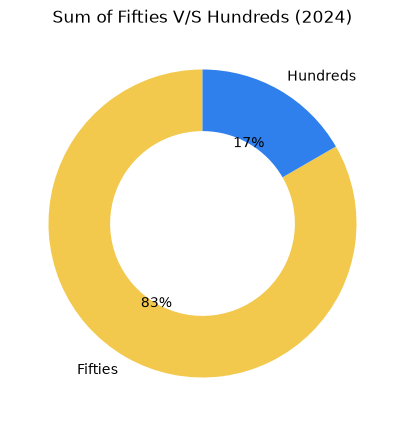

In [247]:
year = 2024   

fifties_total  = orange_cap[orange_cap['Year'] == year]['Fifties'].sum()
hundreds_total = orange_cap[orange_cap['Year'] == year]['Hundreds'].sum()

labels = ['Fifties', 'Hundreds']
values = [fifties_total, hundreds_total]
colors = ['#f2c94c', '#2f80ed']

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(
    values,
    labels=labels,
    colors=colors,
    startangle=90,
    wedgeprops=dict(width=0.4),
    autopct='%1.0f%%'
)
ax.set_title(f"Sum of Fifties V/S Hundreds ({year})")
plt.show()

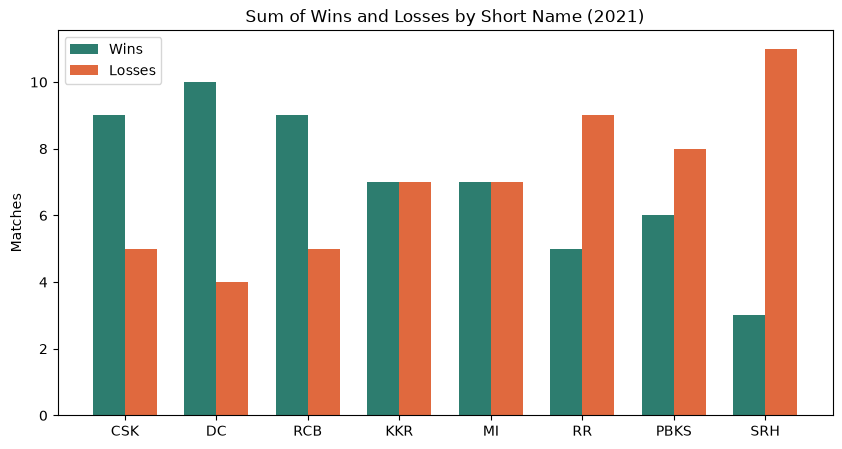

In [248]:
import numpy as np
import matplotlib.pyplot as plt

year = 2021  

# Recalculate data for selected year
team_bar_data = team_perf[team_perf['Year'] == year][['Short Name', 'Wins', 'Losses']].reset_index(drop=True)

x = np.arange(len(team_bar_data))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x - width/2, team_bar_data['Wins'], width, label='Wins', color='#2d7d6f')
ax.bar(x + width/2, team_bar_data['Losses'], width, label='Losses', color='#e0693e')

ax.set_xticks(x)
ax.set_xticklabels(team_bar_data['Short Name'])
ax.set_ylabel("Matches")
ax.set_title(f"Sum of Wins and Losses by Short Name ({year})")
ax.legend()

plt.show()

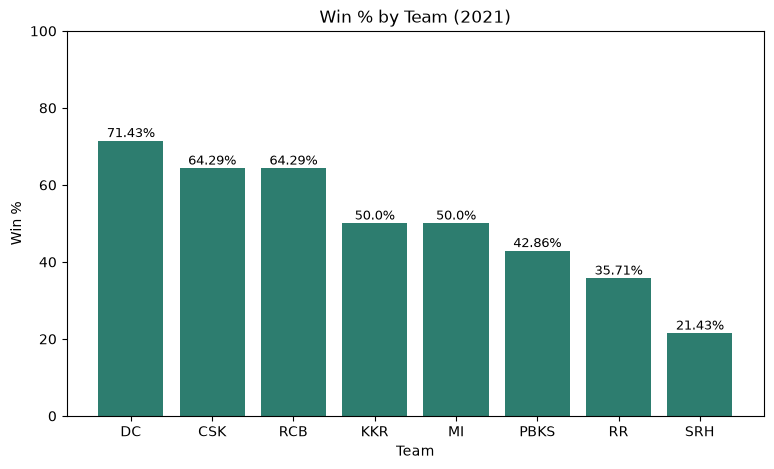

In [249]:
import matplotlib.pyplot as plt

year = 2021  

year_data = team_perf[team_perf['Year'] == year][['Short Name', 'Wins', 'Losses']].copy()
year_data['Win %'] = round((year_data['Wins'] / (year_data['Wins'] + year_data['Losses'])) * 100, 2)
year_data = year_data.sort_values('Win %', ascending=False)

plt.figure(figsize=(9, 5))
bars = plt.bar(year_data['Short Name'], year_data['Win %'], color='#2d7d6f')
plt.title(f"Win % by Team ({year})")
plt.ylabel("Win %")
plt.xlabel("Team")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 1, f'{height}%', 
              ha='center', fontsize=9)

plt.ylim(0, 100)
plt.show()

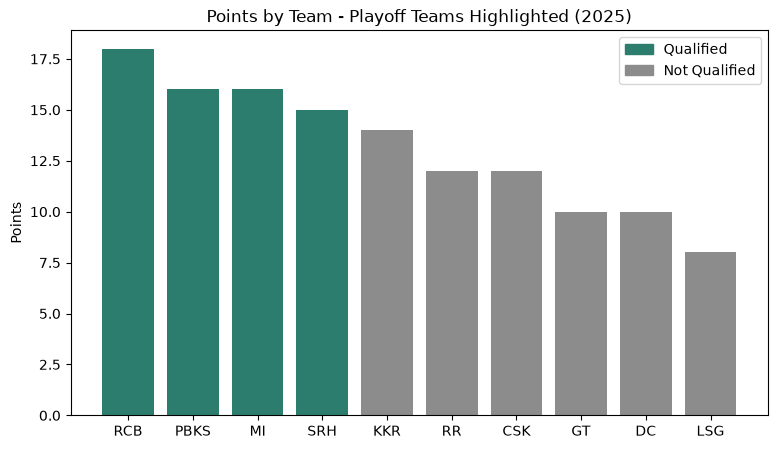

In [250]:
year = 2025   # change this and re-run

playoff_data = team_perf[team_perf['Year'] == year][['Short Name', 'Points', 'Qualified for Playoffs']]
playoff_data = playoff_data.sort_values('Points', ascending=False)

colors = ['#2d7d6f' if q == 'Yes' else '#8c8c8c' for q in playoff_data['Qualified for Playoffs']]

plt.figure(figsize=(9, 5))
bars = plt.bar(playoff_data['Short Name'], playoff_data['Points'], color=colors)
plt.title(f"Points by Team - Playoff Teams Highlighted ({year})")
plt.ylabel("Points")

# legend
import matplotlib.patches as mpatches
green_patch = mpatches.Patch(color='#2d7d6f', label='Qualified')
gray_patch = mpatches.Patch(color='#8c8c8c', label='Not Qualified')
plt.legend(handles=[green_patch, gray_patch])

plt.show()